In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
pd.set_option("display.float_format","{:,.2f}".format)


In [81]:
base_dir = Path.cwd().parent
print(base_dir)
df = pd.read_parquet(f'{base_dir}/files/sales.parquet')

c:\Users\keyne\Documents\Market_Basket_Analysis


In [82]:
# setting the RFM to my clients
clientes = df.groupby('cliente').agg(
    montoventapesos = ('montoventapesos','sum'),
    frecuencia = ('factura', 'nunique'),
    recencia = ('fechafactura',lambda x: (pd.Timestamp.now()-x.max()).days),
    margen = ('margenpesos', 'sum')
).reset_index()


# First sight to the distribution of my data

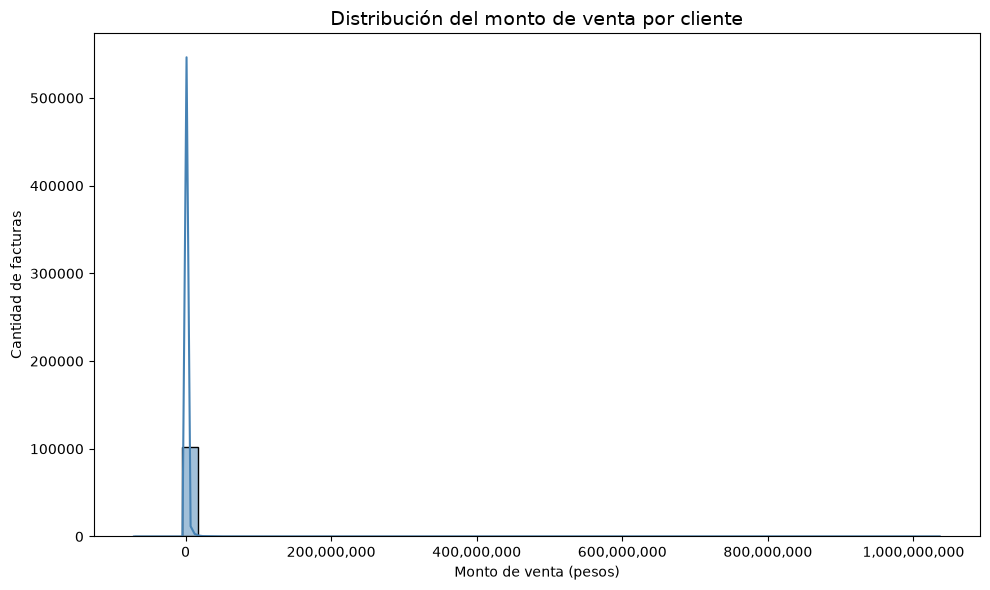

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=clientes,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=ax
)
ax.set_title('Distribución del monto de venta por cliente', fontsize=14)
ax.set_xlabel('Monto de venta (pesos)')
ax.set_ylabel('Cantidad de facturas')
#ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

> ***The data is skewed to the the right, so in this ocassion we are going to apply a log scale (I have done some researchs to look for it)***

In [84]:
devoluciones = clientes[clientes['montoventapesos']<=0]

positive_clients = clientes[(clientes['montoventapesos']>0)&(clientes['margen']>0)]


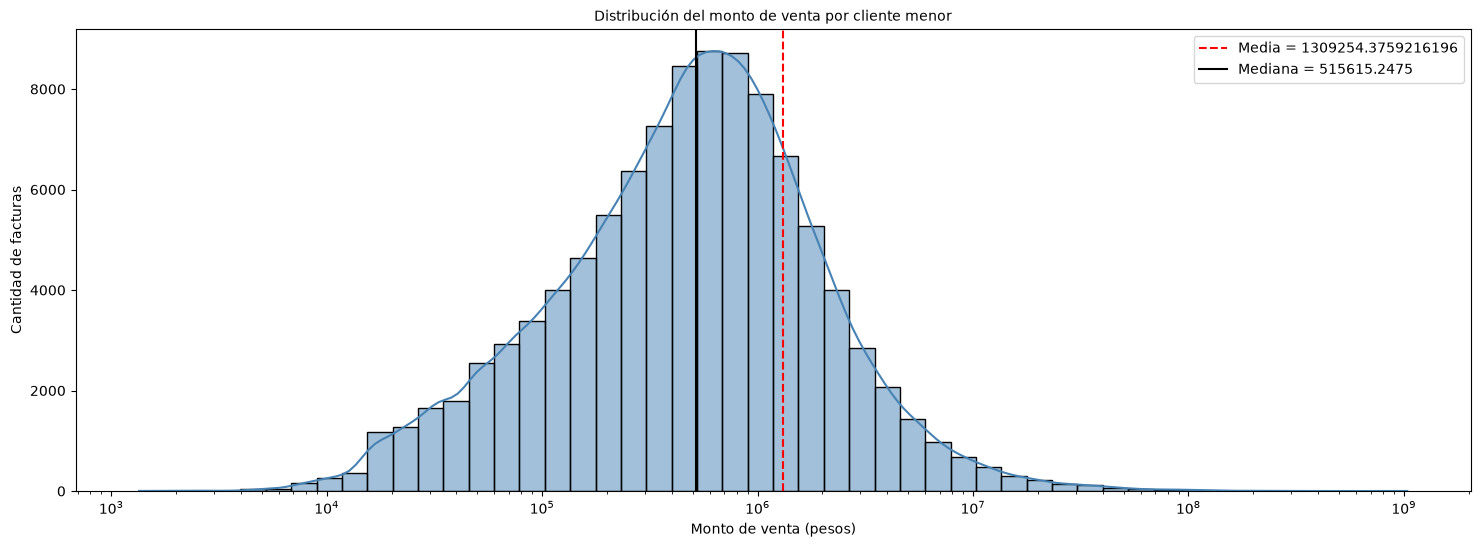

In [85]:
fig, axes = plt.subplots(figsize=(18, 6))
sns.histplot(
    data=positive_clients,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=axes,
    log_scale=True
)

media = positive_clients['montoventapesos'].mean()
median = positive_clients['montoventapesos'].median() 
axes.set_title('Distribución del monto de venta por cliente menor', fontsize=10)
axes.set_xlabel('Monto de venta (pesos)')
axes.set_ylabel('Cantidad de facturas')
axes.axvline(media,label=f'Media = {media}', color= 'red',linestyle='--')
axes.axvline(median,label=f'Mediana = {median}', color= 'black',linestyle='-')
#axes[0].ticklabel_format(style='plain', axis='x')
#axes.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes.legend()

# **Machine Learning**
---

## Escalar los datos

In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler
variables = ['frecuencia','recencia','montoventapesos']

# transforming the values bye columns applying different preprocessing funtions
preprocesador = ColumnTransformer(
    transformers=
    [
        ('recency', MinMaxScaler(),['recencia']),
        ('historial',QuantileTransformer(output_distribution='normal'),['frecuencia']),
        ('value', QuantileTransformer(output_distribution='normal'),['montoventapesos'])
    ],
    transformer_weights={'reciente':5,'historial':4,'value':3}
)

x = positive_clients[variables]
x_scaled = preprocesador.fit_transform(x)

# x_scaled[:,0] = x_scaled[:,0]*5
# x_scaled[:,1] = x_scaled[:,1]*4
# x_scaled[:,2] = x_scaled[:,2]*3
 


> Take into account the a ***log10*** for 0 y ***-inf*** so it gives and error

In [87]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

x_pca_training = pca.fit(x_scaled) 
x_pca = x_pca_training.transform(x_scaled)

positive_clients['pca1'] = x_pca[:,0]
positive_clients['pca2'] = x_pca[:,1]


pd.DataFrame(
    data=pca.components_,
    columns=variables,
    index=['PCA1','PCA2']
)




,frecuencia,recencia,montoventapesos
PCA1,-0.02,0.94,0.34
PCA2,-0.01,-0.35,0.94


<Axes: xlabel='pca1', ylabel='pca2'>

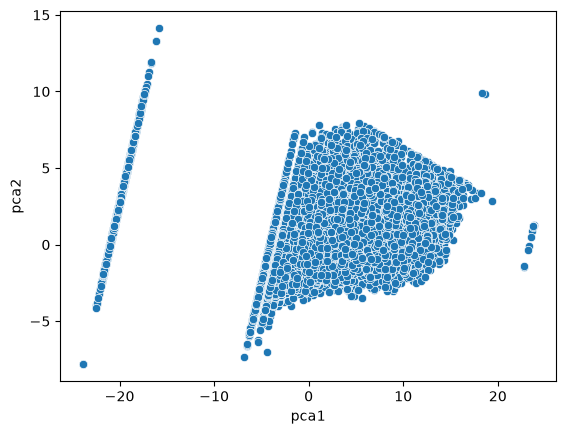

In [88]:
plt.Figure(figsize=(10,14))
sns.scatterplot(
    data=positive_clients,
    x=positive_clients['pca1'],
    y=positive_clients['pca2']
)

## ***Clustering***

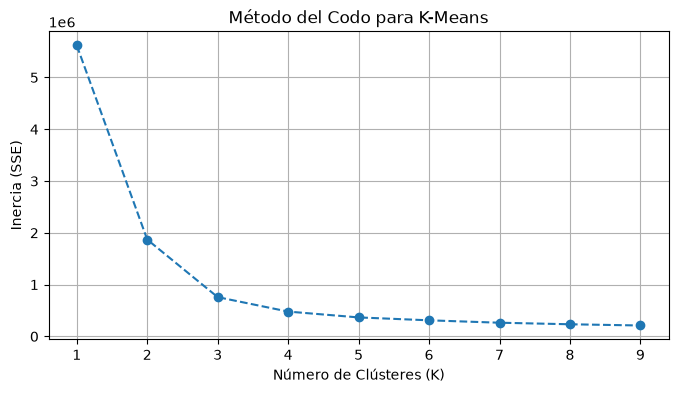

In [89]:
from sklearn.cluster import KMeans

inertia = []
rango = range(1,10)

valores = x_scaled
for i in rango:
    k_means = KMeans(n_clusters=i,random_state=42, n_init=10)
    k_means.fit(valores)
    inertia.append(k_means.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (SSE)')
plt.title('Método del Codo para K-Means')
plt.grid(True)
plt.show()


> Para este tema use un **K_optimo = 3**

In [90]:
K_means= KMeans(n_clusters=3,random_state=42, n_init=1000).fit(valores)

datos = K_means.transform(valores)
print(K_means.cluster_centers_)
positive_clients['cluster'] = K_means.labels_

[[  0.0461589    3.67211304   2.57326244]
 [  0.55802372 -20.79735033  -4.95687059]
 [  0.23854451  -1.90796471  -1.45893169]]


In [91]:
K_means.labels_

array([2, 2, 0, ..., 0, 0, 2], shape=(102610,), dtype=int32)

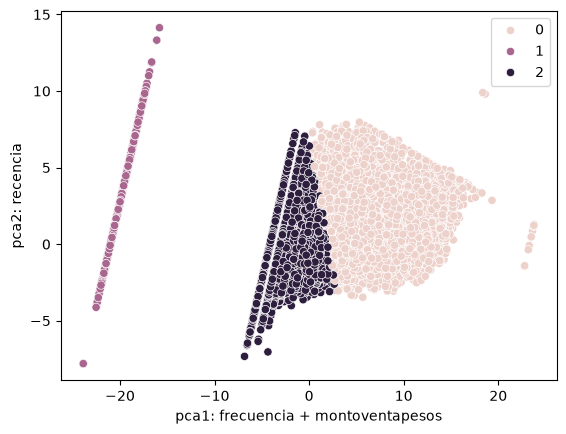

In [92]:
plt.Figure(figsize=(10,14))

sns.scatterplot(
    data=positive_clients,
    x='pca1',
    y='pca2',
    hue= 'cluster'
)

plt.xlabel('pca1: frecuencia + montoventapesos')
plt.ylabel('pca2: recencia')
plt.legend(loc = 'upper right')


## **Merging clusters with the client historial and setting names of each one**

### ***Clusters Analysis***

This next step we start an analysis to see what are the features of each cluster to categorize them propertly 

#### ***Setting name of the clusters***

C:\Users\keyne\AppData\Local\Temp\ipykernel_29248\2348385928.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\keyne\AppData\Local\Temp\ipykernel_29248\2348385928.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\keyne\AppData\Local\Temp\ipykernel_29248\2348385928.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\keyne\AppData\Local\Temp\ipykernel_29248\2348385928.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

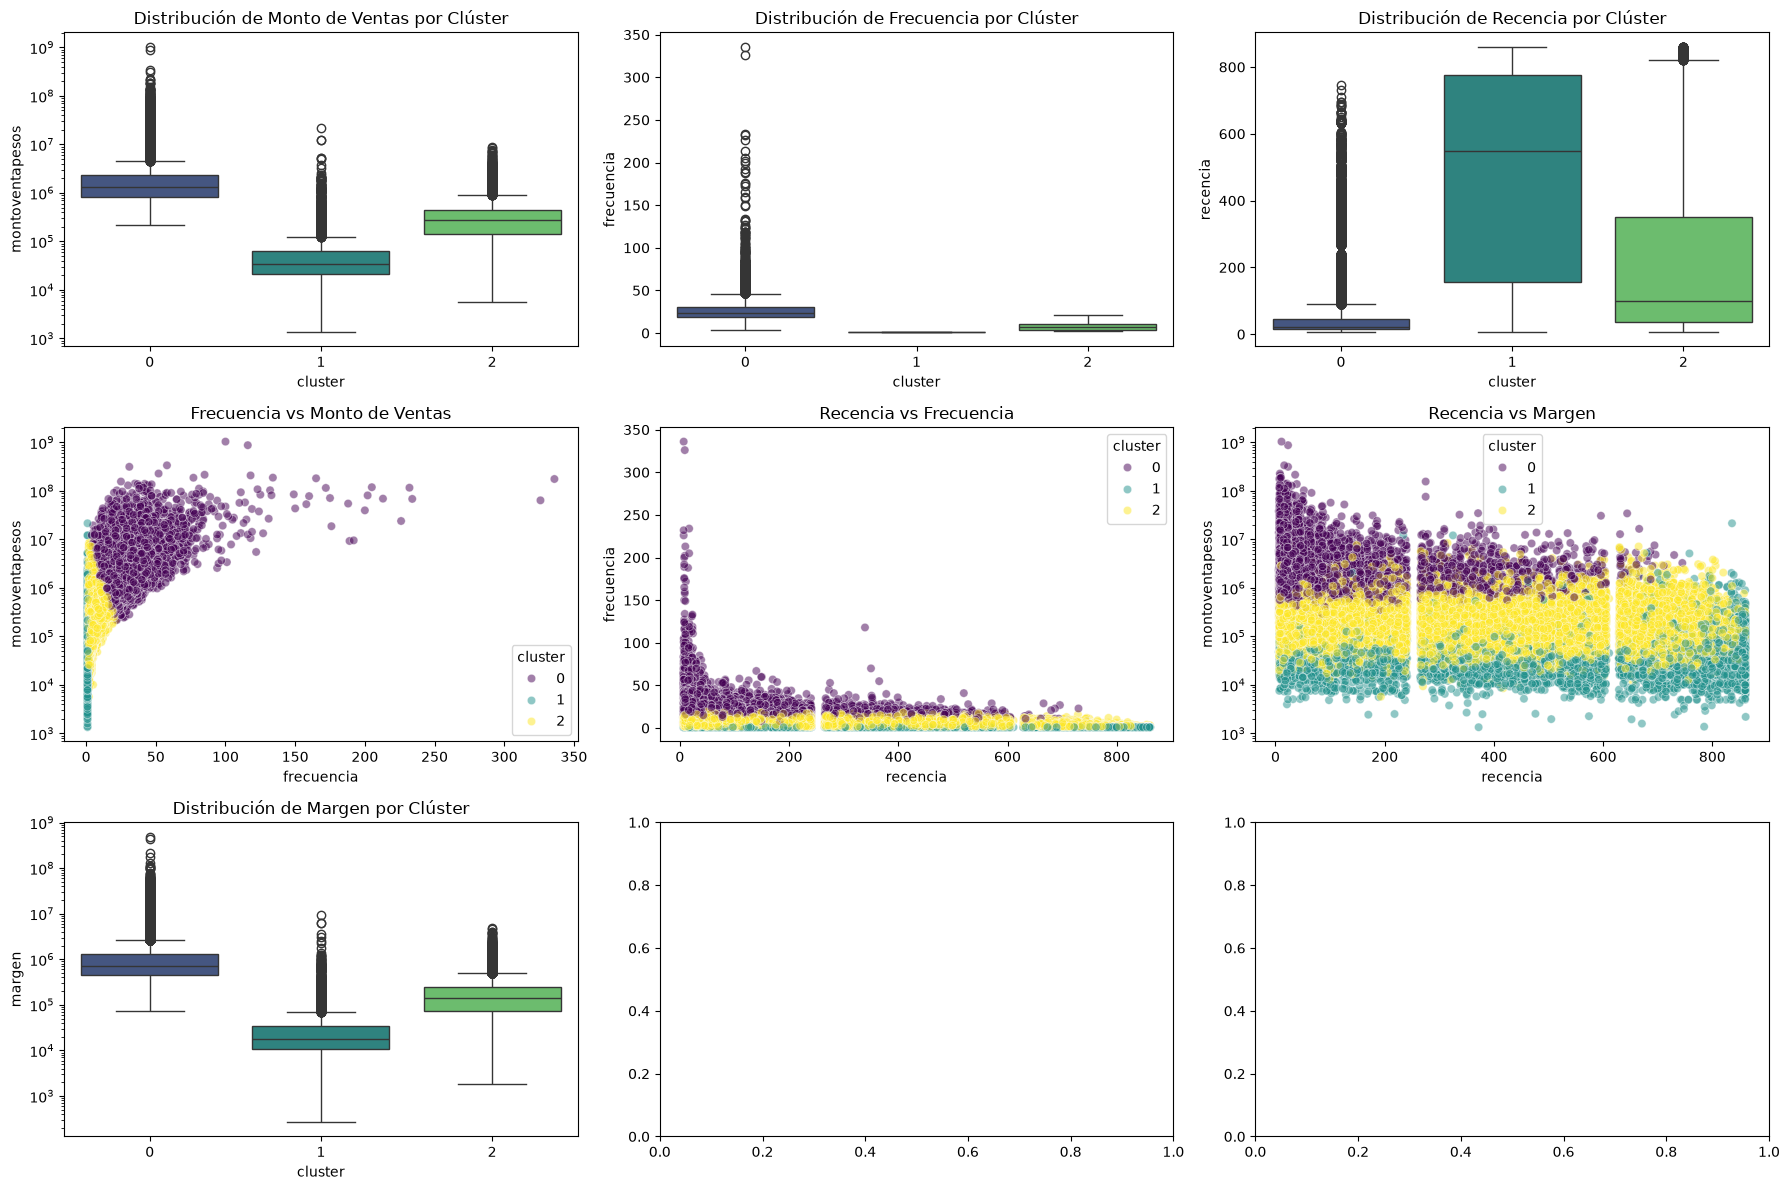

In [93]:
import matplotlib.ticker as ticker

# Crear una figura con múltiples subplots para analizar las dimensiones RFM por clúster
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))

# 1. Boxplot de Monto de Ventas por Clúster
sns.boxplot(
    data=positive_clients, 
    x='cluster', 
    y='montoventapesos', 
    ax=axes[0, 0], 
    palette='viridis'
)
axes[0, 0].set_title('Distribución de Monto de Ventas por Clúster')
axes[0, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[0,0].set_yscale('log')

# 2. Boxplot de Frecuencia por Clúster
sns.boxplot(
    data=positive_clients, 
    x='cluster', 
    y='frecuencia', 
    ax=axes[0, 1], 
    palette='viridis'
)
axes[0, 1].set_title('Distribución de Frecuencia por Clúster')

# 3. Boxplot de Recencia por Clúster
sns.boxplot(
    data=positive_clients, 
    x='cluster', 
    y='recencia', 
    ax=axes[0, 2], 
    palette='viridis'
)
axes[0, 2].set_title('Distribución de Recencia por Clúster')

# 4. Scatter Plot: Frecuencia vs Monto de Ventas
sns.scatterplot(
    data=positive_clients, 
    x='frecuencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 0], 
    alpha=0.5
)
axes[1, 0].set_title('Frecuencia vs Monto de Ventas')
axes[1, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1, 0].set_yscale('log')

# 5. Scatter Plot: Recencia vs Frecuencia
sns.scatterplot(
    data=positive_clients, 
    x='recencia', 
    y='frecuencia', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 1], 
    alpha=0.5
)
axes[1, 1].set_title('Recencia vs Frecuencia')

# 6. Scatter Plot: Recencia vs Monto de Ventas
sns.scatterplot(
    data=positive_clients, 
    x='recencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 2], 
    alpha=0.5
)
axes[1, 2].set_title('Recencia vs Margen')
axes[1, 2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1, 2].set_yscale('log')

sns.boxplot(
    data=positive_clients, 
    x='cluster', 
    y='margen', 
    ax=axes[2,0], 
    palette='viridis'
)
axes[2,0].set_title('Distribución de Margen por Clúster')
axes[2,0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[2,0].set_yscale('log')

plt.tight_layout()
plt.show()

C:\Users\keyne\AppData\Local\Temp\ipykernel_29248\3150760295.py:1: UserWarning: Ignoring `ax`; jointplot is a figure-level function.
  sns.jointplot(


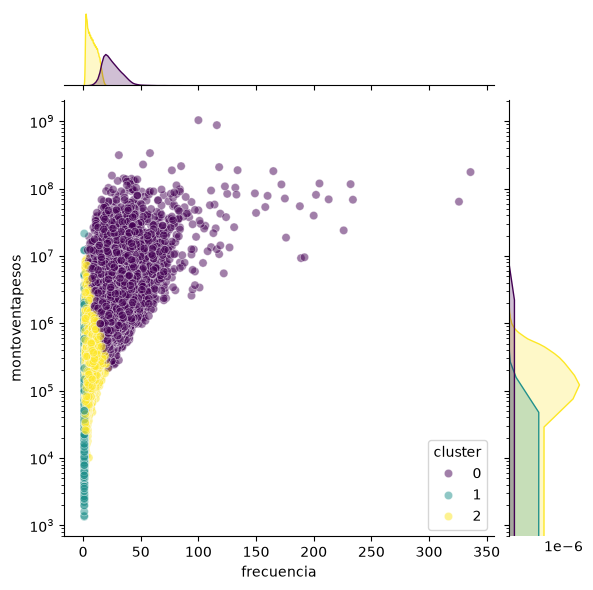

In [94]:
sns.jointplot(
    data=positive_clients, 
    x='frecuencia', 
    y='montoventapesos', 
    hue='cluster', 
    kind='scatter',
    palette='viridis', 
    ax=axes[1, 0], 
    alpha=0.5
)
plt.yscale('log')


## ***Global cluster renaming by median (appended, deletes nothing)***
> Group positive_clients by cluster BEFORE the historical merge and use median + IQR (not mean) because amount / margin / recency are highly skewed.

In [95]:
# 1. Mean vs median comparison per cluster on positive_clients (before merge)
comparison = positive_clients.groupby('cluster').agg(
    n=('cliente','count'),
    rec_mean=('recencia','mean'), rec_median=('recencia','median'), rec_std=('recencia','std'),
    frec_mean=('frecuencia','mean'), frec_median=('frecuencia','median'), frec_std=('frecuencia','std'),
    monto_mean=('montoventapesos','mean'), monto_median=('montoventapesos','median'), monto_std=('montoventapesos','std'),
    margen_mean=('margen','mean'), margen_median=('margen','median')
).reset_index()
comparison['rec_cv'] = comparison['rec_std']/comparison['rec_mean']
comparison['frec_cv'] = comparison['frec_std']/comparison['frec_mean']
comparison['monto_cv'] = comparison['monto_std']/comparison['monto_mean']
# High CV (>1) + skew in amount/margin => median + IQR is more robust than mean
comparison

,cluster,n,rec_mean,rec_median,rec_std,frec_mean,frec_median,frec_std,monto_mean,monto_median,monto_std,margen_mean,margen_median,rec_cv,frec_cv,monto_cv
0,0,43489,45.45,23.00,69.95,24.97,23.00,9.81,"2,666,439.58","1,312,796.41","9,145,394.74","1,487,933.68","717,745.63",1.54,0.39,3.43
1,1,8333,483.11,548.00,304.07,1.00,1.00,0.00,"78,345.53","34,235.18","351,194.02","42,728.41","17,920.84",0.63,0.00,4.48
2,2,50788,209.96,98.00,228.64,7.64,7.00,4.23,"349,077.49","273,177.52","337,617.67","189,606.44","144,025.25",1.09,0.55,0.97


In [96]:
# 2. Conditional script: GLOBAL naming at cluster level with medians (only positive_clients)
# core -> stable pattern (low recency, high frequency and amount)
# leaving -> decaying pattern (intermediate)
# totally_inactives -> dropped long ago (high recency, minimal frequency)
median_profile = positive_clients.groupby("cluster")[
    ["recencia", "frecuencia", "montoventapesos", "margen"]
].median()

# totally_inactives = highest recency median
cluster_inactive = median_profile["recencia"].idxmax()
remaining = median_profile.drop(index=cluster_inactive)

# core = highest frequency median (tie-break by median amount), leaving = the remaining one
remaining_sorted = remaining.sort_values(
    ["frecuencia", "montoventapesos"], ascending=[False, False]
)
cluster_core = remaining_sorted.index[0]
cluster_leaving = remaining_sorted.index[1]

global_mapping = {
    cluster_core: "core",
    cluster_leaving: "leaving",
    cluster_inactive: "totally_inactives",
}

# Create business label in cluster_name, keep numeric cluster intact
positive_clients["cluster_name"] = positive_clients["cluster"].map(global_mapping)

# Global verification by median (only positive_clients, no df_clientes here)
positive_clients.groupby("cluster_name")[
    ["recencia", "frecuencia", "montoventapesos", "margen"]
].median()

,recencia,frecuencia,montoventapesos,margen
cluster_name,,,,
core,23.00,23.00,"1,312,796.41","717,745.63"
leaving,98.00,7.00,"273,177.52","144,025.25"
totally_inactives,548.00,1.00,"34,235.18","17,920.84"


In [97]:
positive_clients

,cliente,montoventapesos,frecuencia,recencia,margen,pca1,pca2,cluster,cluster_name
0,00026326d7,"211,523.26",7,284,"97,492.33",-1.35,-1.48,2,leaving
1,00026bd515,"57,571.37",2,709,"31,363.54",-5.06,-2.50,2,leaving
2,00028b652e,"2,161,848.08",40,23,"1,079,576.36",10.06,0.06,0,core
3,0002972f7d,"1,993,433.63",22,58,"1,122,522.22",4.86,1.79,0,core
4,0002feaa26,"987,933.65",31,29,"580,128.31",6.68,-0.75,0,core
...,...,...,...,...,...,...,...,...,...
102676,fffd1c5da4,"981,773.44",15,43,"524,703.33",2.36,0.82,0,core
102677,fffd502d86,"81,848.53",3,18,"43,505.55",-3.89,-2.29,2,leaving
102678,fffd820c32,"988,058.79",15,78,"518,100.15",2.36,0.84,0,core
102679,fffe9c29fa,"792,652.45",21,16,"489,421.18",3.79,-0.30,0,core


In [100]:
def naming_clusters(df_input):
    """We are using quantiles to categorize the clusters names here"""
    
    df = df_input.copy()

   
    p_rec_baja = df["recencia"].quantile(0.33) 
    p_rec_alta = df["recencia"].quantile(0.66)

    p_frec_alta = df["frecuencia"].quantile(0.75)
    p_frec_media = df["frecuencia"].quantile(0.40)

    p_monto_alto = df["montoventapesos"].quantile(0.75)
    p_monto_bajo = df["montoventapesos"].quantile(0.25)

    # Condition
    def tagging_clusters(row):
        rec = row["recencia"]
        frec = row["frecuencia"]
        monto = row["montoventapesos"]

        # Vip_clients
        if rec <= p_rec_baja and frec >= p_frec_alta and monto >= p_monto_alto:
            return "Champion VIP"

        elif rec <= p_rec_alta and frec >= p_frec_media:
            return "Loyal Clients"
        
        elif rec <= p_rec_baja and frec < p_frec_media:
            return "Promising / Recents"

        elif rec > p_rec_alta and frec >= p_frec_media:
            return "In Risk / To recover"
       
        elif rec > p_rec_alta and frec < p_frec_media:
            return "Inactives / Churn"

        else:
            return "Once in a while"

    # Applying the function
    df["sub_segment"] = df.apply(tagging_clusters, axis=1)

    return df


# Reasinging the dataframe
positive_clients = naming_clusters(positive_clients)

### ***Merging with the client history***

In [101]:
df_clientes = pd.merge(positive_clients[['cliente','cluster','cluster_name','sub_segment']],df, left_on='cliente', right_on='cliente', how='inner')

### ***Clients understanding***

I visualized every cluster with his own different color to see how they behave inside the clusters,and I found that they share the features that I actually want them to have.
As we can see the company has a very close group of clients which overlap specially on recency and frecuency but with a different purchase, and that is when this analysis takes action, in recognizing those clients that are different specially on the ***purchase***, 


In [103]:
resumen_clusters = positive_clients.groupby(['cluster','cluster_name']).agg(
    num_clientes = ('cliente', 'count'),
    recencia_min = ('recencia', 'min'),
    recencia_max = ('recencia', 'max'),
    recencia_median = ('recencia', 'median'),
    recencia_avg = ('recencia', 'mean'),
    frecuencia_min = ('frecuencia', 'min'),
    frecuencia_max = ('frecuencia', 'max'),
    frecuencia_median = ('frecuencia', 'median'),
    frecuencia_avg = ('frecuencia', 'mean'),
    monto_min = ('montoventapesos', 'min'),
    monto_max = ('montoventapesos', 'max'),
    monto_median = ('montoventapesos', 'median'),
    monto_avg = ('montoventapesos', 'mean'),
    margen_min = ('margen', 'min'),
    margen_max = ('margen', 'max'),
    margen_median = ('margen', 'median'),
    margen_avg = ('margen', 'mean')
).reset_index()

resumen_clusters

,cluster,cluster_name,num_clientes,recencia_min,recencia_max,recencia_median,recencia_avg,frecuencia_min,frecuencia_max,frecuencia_median,frecuencia_avg,monto_min,monto_max,monto_median,monto_avg,margen_min,margen_max,margen_median,margen_avg
0,0,core,43489,6,745,23.00,45.45,4,336,23.00,24.97,"217,152.61","1,036,088,953.70","1,312,796.41","2,666,439.58","74,018.74","491,067,982.92","717,745.63","1,487,933.68"
1,1,totally_inactives,8333,6,861,548.00,483.11,1,1,1.00,1.00,"1,344.54","21,484,578.90","34,235.18","78,345.53",266.24,"9,154,297.06","17,920.84","42,728.41"
2,2,leaving,50788,6,861,98.00,209.96,2,21,7.00,7.64,"5,714.29","8,999,970.00","273,177.52","349,077.49","1,798.41","4,734,257.35","144,025.25","189,606.44"


## ***Jobbing for the model***

In [104]:
import joblib

artifacts = {
    'preprocessor': preprocesador,
    'kmeans': K_means,
    'pca':x_pca_training
}

joblib.dump(artifacts, 'clustering_rfm_model.pkl')

['clustering_rfm_model.pkl']

In [105]:
df_clientes.to_csv(f'{base_dir}/files/segmentos.csv')